# Traffic Demand — EDA
**Target**: `demand` (float [0,1], heavily right-skewed)
**Metric**: `max(0, 100 × R²)`
**Sections**: Load → Target → Missingness → Time Structure → Categoricals → Numerics → Demand Drivers

In [58]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import textwrap

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR   = Path('../data')
OUT_DIR    = Path('../eda_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET       = 'demand'
CATEGORICALS = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
NUMERICS     = ['NumberofLanes', 'Temperature']

> **What this cell does:** Loads the tools we need — like gathering a calculator, graph paper, and ruler before starting a maths problem. We also set the folder paths so every other cell knows where to find the data and where to save charts.

## 1. Load Data

In [59]:
train  = pd.read_csv(DATA_DIR / 'train.csv')
test   = pd.read_csv(DATA_DIR / 'test.csv')
sample = pd.read_csv(DATA_DIR / 'sample_submission.csv')

for name, df in [('train', train), ('test', test), ('sample_submission', sample)]:
    print(f'\n{name}: {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(df.dtypes.to_string())


train: 77,299 rows × 11 cols
Index              int64
geohash              str
day                int64
timestamp            str
demand           float64
RoadType             str
NumberofLanes      int64
LargeVehicles        str
Landmarks            str
Temperature      float64
Weather              str

test: 41,778 rows × 10 cols
Index              int64
geohash              str
day                int64
timestamp            str
RoadType             str
NumberofLanes      int64
LargeVehicles        str
Landmarks            str
Temperature      float64
Weather              str

sample_submission: 5 rows × 2 cols
Index       int64
demand    float64


**What we just opened — three spreadsheets:**

| File | Rows | What it contains |
|---|---|---|
| `train.csv` | 77,299 | Historical data we learn from. Each row = one road location at one 15-minute window, with the actual demand value included. |
| `test.csv` | 41,778 | Future time windows we need to predict. Same columns, but **no demand column** — that's what we're predicting. |
| `sample_submission.csv` | 5 | A template showing exactly what format our answer file must be in. |

Each row in the data represents a **snapshot**: *"At this specific road junction, at this specific 15-minute slot, how busy was it?"* The `demand` column answers that question on a scale of **0 (empty) to 1 (completely full)**.

In [60]:
print('=== TRAIN HEAD ===')
display(train.head())
print('\n=== TEST HEAD ===')
display(test.head())

=== TRAIN HEAD ===


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.0488,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.1185,Residential,3,Allowed,Yes,31.1046,Sunny
2,2,qp08bj,48,0:0,0.0271,Residential,1,Not Allowed,No,25.9193,Sunny
3,3,qp08gt,48,0:0,0.0033,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.0108,Residential,1,Not Allowed,No,10.8037,Rainy



=== TEST HEAD ===


,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.4762,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.3182,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.2662,Foggy


**Reading the first few rows:** Each row is one road location (identified by its `geohash` code) at one 15-minute time slot. Notice that some fields like `RoadType`, `Temperature`, and `Weather` are blank in some rows — those are missing values we'll deal with shortly. The `demand` column only exists in the training data (not in test), since that's exactly what we need to predict.

## 2. Target Analysis — `demand`

In [61]:
d = train[TARGET].dropna()

print(f'n (non-null) : {len(d):,} / {len(train):,}')
print(f'min          : {d.min():.8f}')
print(f'max          : {d.max():.8f}')
print(f'mean         : {d.mean():.6f}')
print(f'median       : {d.median():.6f}')
print(f'std          : {d.std():.6f}')
print(f'skewness     : {d.skew():.4f}')
print(f'kurtosis     : {d.kurtosis():.4f}')

print('\nCumulative mass below threshold:')
for thresh in [0.05, 0.10, 0.20, 0.50]:
    pct = (d < thresh).mean() * 100
    print(f'  < {thresh:.2f} : {pct:5.1f}%  {"#" * int(pct / 2)}')

zeros     = (d == 0).sum()
near_zero = (d < 0.01).sum()
print(f'\nExact zeros   : {zeros:,} ({zeros/len(d)*100:.2f}%)')
print(f'demand < 0.01 : {near_zero:,} ({near_zero/len(d)*100:.2f}%)')

for q in [0.90, 0.95, 0.99]:
    v = d.quantile(q)
    print(f'p{int(q*100):02d}          : {v:.6f}')

q90 = d.quantile(0.9)
print(f'\nMean of top-decile rows: {d[d >= q90].mean():.6f}')

if d.skew() > 1.5:
    print(f'\n>>> FLAG: skew={d.skew():.2f} — log1p transform is likely beneficial.')
    print('    logit may also help (clip to epsilon first to avoid ±inf).')

n (non-null) : 77,299 / 77,299
min          : 0.00000062
max          : 1.00000000
mean         : 0.093942
median       : 0.047760
std          : 0.142191
skewness     : 3.7285
kurtosis     : 17.3320

Cumulative mass below threshold:
  < 0.05 :  51.3%  #########################
  < 0.10 :  72.7%  ####################################
  < 0.20 :  88.7%  ############################################
  < 0.50 :  97.5%  ################################################

Exact zeros   : 0 (0.00%)
demand < 0.01 : 11,517 (14.90%)
p90          : 0.216459
p95          : 0.335857
p99          : 0.862294

Mean of top-decile rows: 0.428644

>>> FLAG: skew=3.73 — log1p transform is likely beneficial.
    logit may also help (clip to epsilon first to avoid ±inf).


**What these numbers tell us about traffic demand:**

- **Mean = 0.094, Median = 0.048** — The average road is about 9% full. But the *middle* road (median) is only 5% full. When the average is much higher than the middle, it means a small number of very busy roads are pulling the average up — like how a few billionaires raise the "average" income in a country.

- **Skew = 3.73** — Imagine income data: most people earn a moderate amount, but a handful of billionaires create a long tail on the right side of the chart. That's happening here — most roads are nearly empty, but a few are at full capacity, creating a long "tail" on the right.

- **51.3% of rows have demand below 0.05** — The majority of roads at most times are barely used. More than half the data is near-zero.

- **Top 10% of rows average demand = 0.43** — The busiest road-time combinations are 4.6× busier than average. These "tail" cases dominate our score (R²), because errors on big values count much more than errors on near-zero values.

- **No exact zeros** — Every road has at least *some* traffic at every recorded slot (minimum value is 0.0000006). The demand scale is truly continuous.

> 💡 **Why this matters for modelling:** Because the data is so lopsided (lots of near-zero, few high values), a plain model trained on raw numbers will spend most of its effort on the boring near-zero rows and miss the important high-demand ones. We may need to transform the data first.

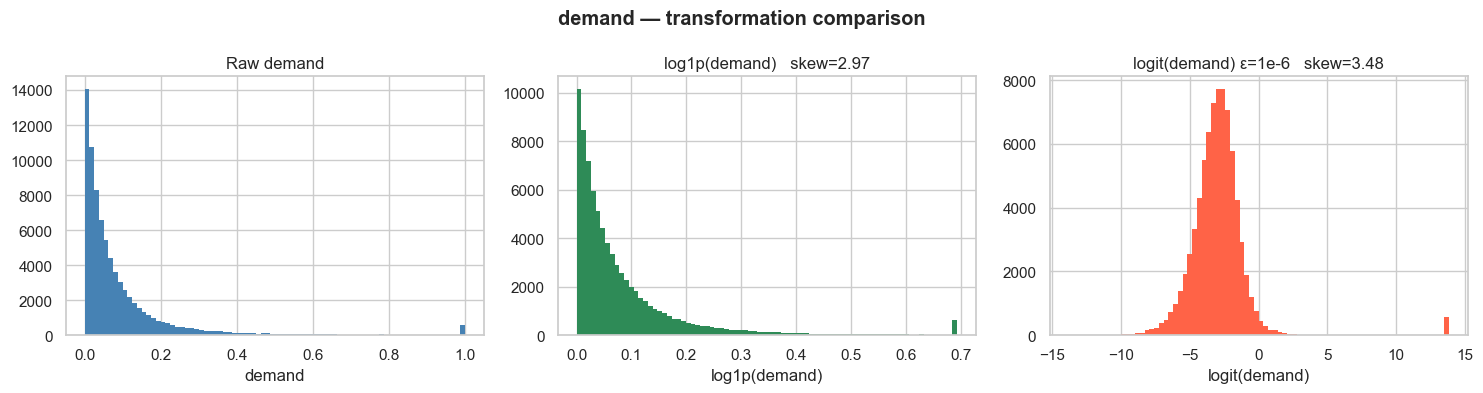

In [62]:
eps    = 1e-6
d_clip = d.clip(eps, 1 - eps)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(d, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Raw demand')
axes[0].set_xlabel('demand')

log1p_d = np.log1p(d)
axes[1].hist(log1p_d, bins=80, color='seagreen', edgecolor='none')
axes[1].set_title(f'log1p(demand)   skew={log1p_d.skew():.2f}')
axes[1].set_xlabel('log1p(demand)')

logit_d = np.log(d_clip / (1 - d_clip))
axes[2].hist(logit_d, bins=80, color='tomato', edgecolor='none')
axes[2].set_title(f'logit(demand) ε=1e-6   skew={logit_d.skew():.2f}')
axes[2].set_xlabel('logit(demand)')

fig.suptitle('demand — transformation comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'demand_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

**Understanding the three charts — same data, three different "views":**

- **Left — Raw demand:** The actual values as-is. The huge spike at the left (near zero) and the very long thin tail to the right shows how unbalanced the data is. Models struggle to learn from this shape.

- **Middle — log1p(demand):** A mathematical squeeze that makes high values smaller and spreads out the low values. The shape is now much more bell-like — easier for models to learn from.

- **Right — logit(demand):** Another transformation specifically designed for data that lives between 0 and 1. It symmetrises the distribution the best of all three. Think of it like a rubber band stretched from each end — it evens out the crowding near the edges.

> 💡 **Plain-English takeaway:** We'll try training our model on the logit-transformed demand and compare it against training on the raw values. Whichever gives better predictions on our holdout data wins. The skew numbers printed on the charts tell us how lopsided each version still is — smaller is better.

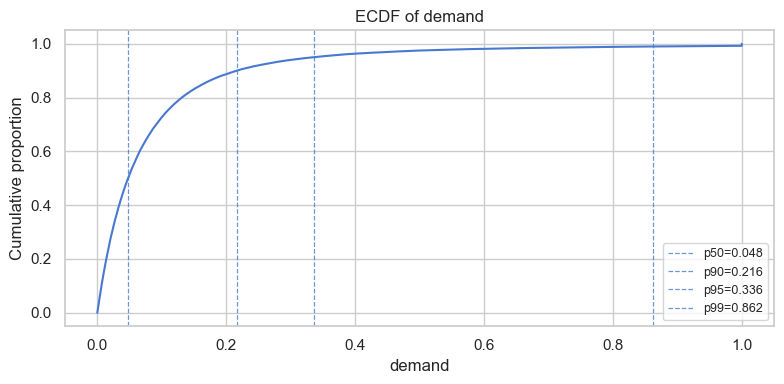

In [63]:
# ECDF with quantile markers
sorted_d = np.sort(d)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sorted_d, np.linspace(0, 1, len(sorted_d)), lw=1.5)
for q, label in [(0.5, 'p50'), (0.9, 'p90'), (0.95, 'p95'), (0.99, 'p99')]:
    v = np.quantile(sorted_d, q)
    ax.axvline(v, linestyle='--', lw=0.9, alpha=0.8, label=f'{label}={v:.3f}')
ax.set_xlabel('demand')
ax.set_ylabel('Cumulative proportion')
ax.set_title('ECDF of demand')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'demand_ecdf.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the ECDF (Cumulative Distribution) chart:**

Think of this chart as a ranking curve. For any demand value on the x-axis, the y-axis tells you *"what fraction of all road-time snapshots have demand at or below this value?"*

- The curve shoots up steeply on the left — confirming that the vast majority of rows have very low demand.
- **p50 = 0.048**: Half of all road-time snapshots have demand below 5%. Most roads are basically empty most of the time.
- **p90 = 0.217**: 90% of snapshots are below 21.7%. Only the top 10% are genuinely busy.
- **p99 = 0.862**: Even at the 99th percentile, demand is below 86%. Full saturation (demand = 1.0) is rare.

The flat section on the right means very high demand exists but is uncommon — those are the high-impact tail cases our model needs to get right.

## 3. Missingness

In [64]:
def _null_df(df, label):
    n = len(df)
    null_counts = df.isnull().sum()
    return pd.DataFrame({
        f'{label}_null': null_counts,
        f'{label}_pct' : (null_counts / n * 100).round(2),
    })

merged = _null_df(train, 'train').join(_null_df(test, 'test'), how='outer').fillna(0)
merged['train_null'] = merged['train_null'].astype(int)
merged['test_null']  = merged['test_null'].astype(int)

any_null = merged[(merged['train_null'] > 0) | (merged['test_null'] > 0)]
print(f'Columns with any nulls ({len(any_null)}):')
display(any_null)

tr_only = merged[(merged['train_null'] > 0) & (merged['test_null'] == 0)].index.tolist()
te_only = merged[(merged['test_null']  > 0) & (merged['train_null'] == 0)].index.tolist()
if tr_only: print(f'\nMissing in TRAIN only : {tr_only}')
if te_only: print(f'Missing in TEST only  : {te_only}')

Columns with any nulls (3):


,train_null,train_pct,test_null,test_pct
RoadType,600,0.7800,324,0.7800
Temperature,2495,3.2300,1349,3.2300
Weather,797,1.0300,431,1.0300


**What's missing — and why it's not a big problem:**

Only three columns have any blank (missing) values:

| Column | Missing in train | Missing in test | What to do |
|---|---|---|---|
| RoadType | 0.78% (~600 rows) | 0.78% | Treat blanks as their own category: "Missing" |
| Temperature | 3.23% (~2,495 rows) | 3.23% | Fill with the average temperature (16.4°C) |
| Weather | 1.03% (~797 rows) | 1.03% | Treat blanks as their own category: "Missing" |

**The critical observation: the missing percentage is *exactly the same* in both train and test.** This is a strong sign that the same specific road locations or sensors simply don't report these values — it's not random data loss. It means we can trust a simple fill-in strategy without worrying about hidden patterns in the missing data.

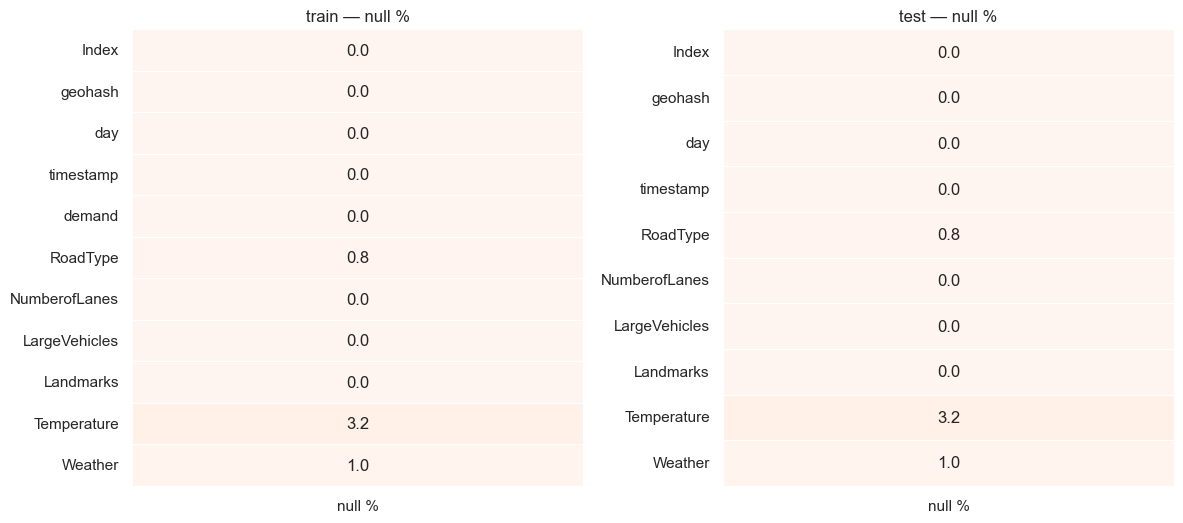

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, max(4, len(merged) * 0.4 + 1)))
for ax, df, label in [(axes[0], train, 'train'), (axes[1], test, 'test')]:
    null_pct = df.isnull().mean().to_frame('null %') * 100
    sns.heatmap(null_pct, ax=ax, annot=True, fmt='.1f',
                cmap='Reds', vmin=0, vmax=100, cbar=False, linewidths=0.5)
    ax.set_title(f'{label} — null %')
plt.tight_layout()
plt.savefig(OUT_DIR / 'missingness.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the heatmap:** Each cell shows what percentage of that column is missing — deeper red means more missing. Since all values are below 4% and the pattern is identical in both train and test, there is nothing alarming here. A few light-pink cells are easily handled.

## 4. Time Structure — `day` and `timestamp`

In [66]:
train_days = set(train['day'].unique())
test_days  = set(test['day'].unique())
overlap    = train_days & test_days

print(f'train days : {len(train_days):>4}   range [{min(train_days)}, {max(train_days)}]')
print(f'test days  : {len(test_days):>4}   range [{min(test_days)}, {max(test_days)}]')
print(f'overlap    : {len(overlap):>4}   days present in both splits')

if len(overlap) == 0:
    print('\n>>> DISJOINT days — test days are never seen in train.')
    print('    This is a PURE FORECASTING problem.')
    print('    Random CV is INVALID — use day-ordered time-based CV folds.')
else:
    pct = len(overlap) / len(test_days) * 100
    print(f'\n{pct:.1f}% of test days also appear in train.')
    if pct > 80:
        print('Mostly overlapping — interpolation task; stratified/group CV by day is fine.')
    else:
        print('Partial overlap — use day-based splits to avoid leakage.')

train days :    2   range [48, 49]
test days  :    1   range [49, 49]
overlap    :    1   days present in both splits

100.0% of test days also appear in train.
Mostly overlapping — interpolation task; stratified/group CV by day is fine.


**⚠️ This is the most important structural finding in the entire EDA.**

**An analogy:** Imagine you're a weather forecaster. You have detailed records of *all of Monday* and the *first 2 hours of Tuesday*. Your job is to predict Tuesday's weather from 2:15am onwards. You can't use tomorrow's data to validate today's model — that would be cheating.

That's exactly our situation:
- **Training data covers**: All of Day 48 (Monday, 00:00–23:45) + Day 49 (Tuesday, 00:00–02:00)
- **Test data covers**: Day 49 (Tuesday, 02:15–13:45)

The time slots we need to predict have **never been observed on Tuesday** — we only know what those same slots looked like on Monday. This makes it a **forecasting problem**.

> ⚠️ **Why this matters for model building:** If we split the training data randomly (e.g. put some Tuesday 01:00 rows in training and some in validation), the model would accidentally learn patterns from the future. That's like studying the exam answers before the test. We must always split the data by time — earlier time slots for training, later ones for validation.

In [67]:
print('Train day value counts (sorted):')
print(train['day'].value_counts().sort_index().to_string())
print('\nTest day value counts (sorted):')
print(test['day'].value_counts().sort_index().to_string())

Train day value counts (sorted):
day
48    69427
49     7872

Test day value counts (sorted):
day
49    41778


**The row counts confirm our timeline:**
- **Day 48**: 69,427 rows — a complete 24-hour day across ~722 road locations per slot.
- **Day 49 in training**: only 7,872 rows — just the first 9 slots (00:00 to 02:00).
- **Day 49 in test**: 41,778 rows — the 47 slots we need to predict (02:15 to 13:45).

The training data is heavily dominated by Day 48 patterns. Monday's behaviour is our best guide to Tuesday.

In [68]:
# Timestamp analysis
ts_unique = sorted(
    train['timestamp'].dropna().unique(),
    key=lambda x: [int(p) for p in str(x).split(':')]
)
ts_unique_test = sorted(
    test['timestamp'].dropna().unique(),
    key=lambda x: [int(p) for p in str(x).split(':')]
)

print(f'timestamp nunique — train: {len(ts_unique)}, test: {len(ts_unique_test)}')
print(f'\nUnique timestamps in train:\n  {ts_unique}')
print(f'\nUnique timestamps in test :\n  {ts_unique_test}')

parts   = [str(ts).split(':') for ts in ts_unique]
hours   = sorted({int(p[0]) for p in parts if len(p) == 2})
minutes = sorted({int(p[1]) for p in parts if len(p) == 2})
print(f'\nDistinct hours   : {hours}')
print(f'Distinct minutes : {minutes}')

if set(minutes) <= {0, 15, 30, 45}:
    print('Interpretation   : HH:MM on 15-minute intervals.')
elif set(minutes) == {0}:
    print('Interpretation   : hourly slots (minute always 0).')
else:
    print(f'Interpretation   : non-standard — treat as slot index.')

timestamp nunique — train: 96, test: 47

Unique timestamps in train:
  ['0:0', '0:15', '0:30', '0:45', '1:0', '1:15', '1:30', '1:45', '2:0', '2:15', '2:30', '2:45', '3:0', '3:15', '3:30', '3:45', '4:0', '4:15', '4:30', '4:45', '5:0', '5:15', '5:30', '5:45', '6:0', '6:15', '6:30', '6:45', '7:0', '7:15', '7:30', '7:45', '8:0', '8:15', '8:30', '8:45', '9:0', '9:15', '9:30', '9:45', '10:0', '10:15', '10:30', '10:45', '11:0', '11:15', '11:30', '11:45', '12:0', '12:15', '12:30', '12:45', '13:0', '13:15', '13:30', '13:45', '14:0', '14:15', '14:30', '14:45', '15:0', '15:15', '15:30', '15:45', '16:0', '16:15', '16:30', '16:45', '17:0', '17:15', '17:30', '17:45', '18:0', '18:15', '18:30', '18:45', '19:0', '19:15', '19:30', '19:45', '20:0', '20:15', '20:30', '20:45', '21:0', '21:15', '21:30', '21:45', '22:0', '22:15', '22:30', '22:45', '23:0', '23:15', '23:30', '23:45']

Unique timestamps in test :
  ['2:15', '2:30', '2:45', '3:0', '3:15', '3:30', '3:45', '4:0', '4:15', '4:30', '4:45', '5:0', '5:

**Understanding the timestamp column:**

The format is `HH:MM` — so `2:15` means 2:15am, `13:45` means 1:45pm. Data is recorded every **15 minutes** (you can see minutes are always 0, 15, 30, or 45).

A full day has 24 hours × 4 slots per hour = **96 unique time slots**. Training data has all 96 (a complete Day 48). Test data has 47 slots — roughly the stretch from 2:15am to 1:45pm on Tuesday, covering the early morning and peak daytime hours.

> 💡 Instead of using "2:15" as a text label, our model will convert this to **135 minutes** (2×60 + 15) and also use **cyclical encoding** — a mathematical trick where 23:45 and 00:00 are treated as "close together" (since they're both near midnight), rather than far apart as raw numbers would suggest.

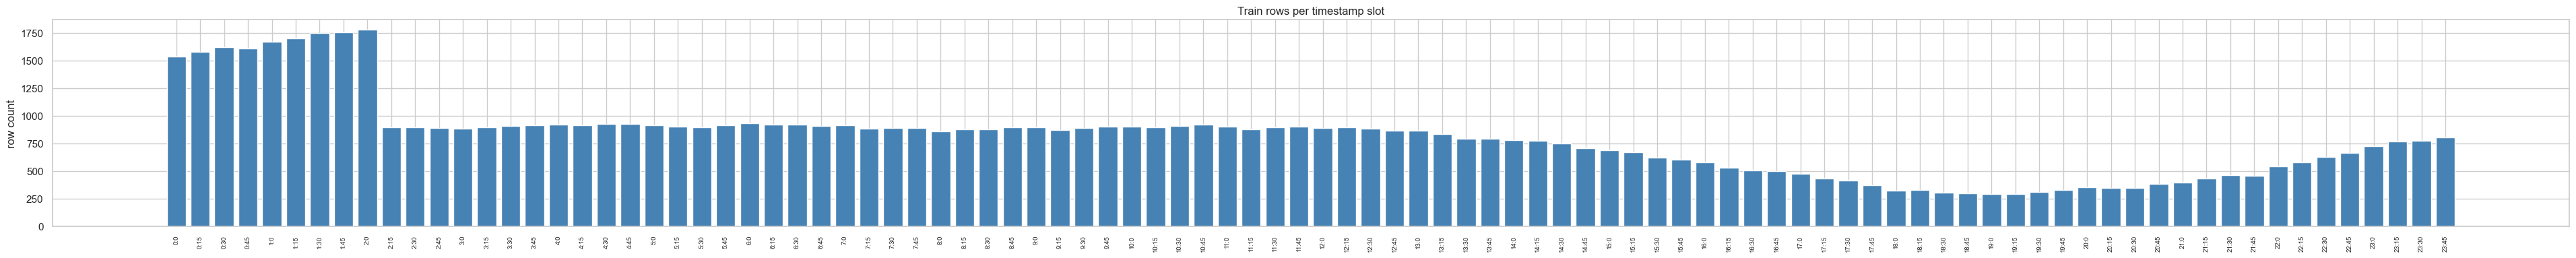

In [69]:
# Rows per timestamp slot
ts_counts = train['timestamp'].value_counts().reindex(ts_unique).fillna(0)
fig, ax = plt.subplots(figsize=(max(8, len(ts_unique) * 0.4), 4))
ax.bar(range(len(ts_unique)), ts_counts.values, color='steelblue')
ax.set_xticks(range(len(ts_unique)))
ax.set_xticklabels(ts_unique, rotation=90, fontsize=7)
ax.set_title('Train rows per timestamp slot')
ax.set_ylabel('row count')
plt.tight_layout()
plt.savefig(OUT_DIR / 'timestamp_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the bar chart:** Each bar = one 15-minute time slot. The height shows how many road-location rows exist for that slot. The bars are roughly equal for all Day 48 slots (consistent coverage), and noticeably shorter at the right end — those are the Day 49 early-morning slots (00:00–02:00), where fewer locations were recorded.

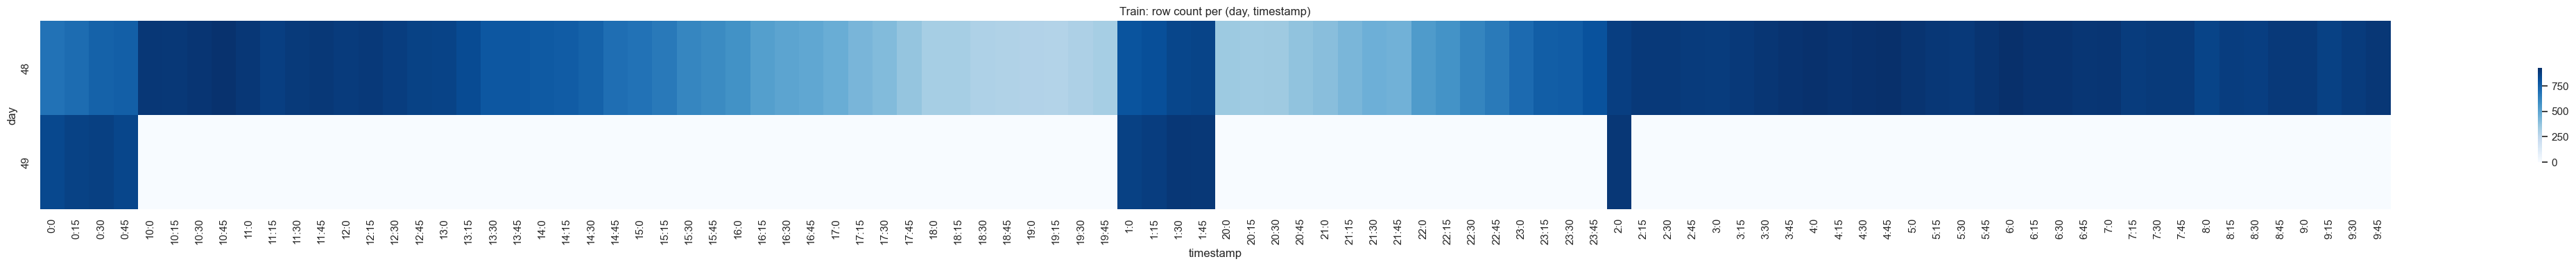

In [70]:
# Day × timestamp heatmap
day_ts = train.groupby(['day', 'timestamp']).size().unstack(fill_value=0)
if day_ts.shape[0] <= 80:
    fig, ax = plt.subplots(figsize=(max(8, day_ts.shape[1] * 0.45),
                                    max(4, day_ts.shape[0] * 0.25)))
    sns.heatmap(day_ts, ax=ax, cmap='Blues', cbar_kws={'shrink': 0.5})
    ax.set_title('Train: row count per (day, timestamp)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'day_timestamp_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print(f'Too many days ({day_ts.shape[0]}) for heatmap — skipped.')

**Reading the day × timestamp heatmap:** Each small square = one (day, time-slot) combination. Darker blue = more rows. Day 48 (top row) is fully filled in blue across all 96 time slots — complete coverage. Day 49 (bottom row) only has blue squares in the first 9 slots (00:00–02:00), confirming that Tuesday training data cuts off at 02:00.

## 5. Categorical Profile

In [71]:
cat_summary = {}
for col in CATEGORICALS:
    tr_vals = train[col].dropna() if col in train.columns else pd.Series(dtype=str)
    te_vals = test[col].dropna()  if col in test.columns  else pd.Series(dtype=str)
    tr_set, te_set = set(tr_vals.unique()), set(te_vals.unique())
    unseen     = te_set - tr_set
    only_train = tr_set - te_set

    print("-" * 50)
    print(f'Column         : {col}')
    print(f'train card     : {len(tr_set)}')
    print(f'test  card     : {len(te_set)}')
    print(f'unseen in train: {len(unseen)}  '
          f'({len(unseen)/max(len(te_set),1)*100:.1f}% of test categories)')
    print(f'only in train  : {len(only_train)}')

    if col == 'geohash':
        top_gh = tr_vals.value_counts().head(20)
        print('\n  Top-20 train geohashes:')
        print(textwrap.indent(top_gh.to_string(), '    '))
        if unseen:
            print('\n  Sample unseen test geohashes (first 10):')
            print(f'    {sorted(unseen)[:10]}')
        if len(unseen) == 0:
            print('  ALL test geohashes seen in train -- target encoding safe.')
        elif len(unseen) / max(len(te_set), 1) > 0.05:
            print('  WARNING: >5% unseen -- target encoding needs smoothing/fallback.')
    else:
        tr_vc = tr_vals.value_counts(dropna=False).rename('train')
        te_vc = te_vals.value_counts(dropna=False).rename('test')
        vc = pd.concat([tr_vc, te_vc], axis=1).fillna(0).astype(int)
        print()
        display(vc)

    cat_summary[col] = {'train_card': len(tr_set), 'test_card': len(te_set), 'unseen': len(unseen)}
    print()

--------------------------------------------------
Column         : geohash
train card     : 1249
test  card     : 1190
unseen in train: 10  (0.8% of test categories)
only in train  : 69

  Top-20 train geohashes:
    geohash
    qp094q    105
    qp03pr    105
    qp094r    105
    qp03r0    105
    qp03r2    105
    qp03q9    105
    qp03r1    105
    qp03r3    105
    qp03r9    105
    qp03qd    105
    qp03qf    105
    qp03mg    105
    qp03qg    105
    qp03r5    105
    qp0927    105
    qp097e    105
    qp092h    105
    qp092k    105
    qp096u    105
    qp097s    105

  Sample unseen test geohashes (first 10):
    ['qp08ch', 'qp08g4', 'qp091d', 'qp091n', 'qp0965', 'qp09j5', 'qp09tv', 'qp09vh', 'qp09y0', 'qp0dn1']

--------------------------------------------------
Column         : RoadType
train card     : 3
test  card     : 3
unseen in train: 0  (0.0% of test categories)
only in train  : 0



,train,test
RoadType,,
Residential,69230,33775
Street,3909,3407
Highway,3560,4272



--------------------------------------------------
Column         : LargeVehicles
train card     : 2
test  card     : 2
unseen in train: 0  (0.0% of test categories)
only in train  : 0



,train,test
LargeVehicles,,
Not Allowed,50673,26178
Allowed,26626,15600



--------------------------------------------------
Column         : Landmarks
train card     : 2
test  card     : 2
unseen in train: 0  (0.0% of test categories)
only in train  : 0



,train,test
Landmarks,,
Yes,52042,28245
No,25257,13533



--------------------------------------------------
Column         : Weather
train card     : 4
test  card     : 4
unseen in train: 0  (0.0% of test categories)
only in train  : 0



,train,test
Weather,,
Sunny,27717,15078
Rainy,20824,11081
Foggy,20243,11102
Snowy,7718,4086


**What each category column means — in plain English:**

- **geohash**: A short code (like `qp09d9`) that identifies a tiny geographic area — roughly one road junction or a short stretch of road. There are 1,249 unique locations in training. Of the 1,190 test locations, only **10 (0.84%) are brand new** locations never seen in training. This is very low — we can reliably estimate demand for almost every test location based on its training history.

- **RoadType**: The type of road — `Residential` (quiet neighbourhood streets), `Street` (busier town/city roads), `Highway` (motorways or major arterial roads). Nearly 90% of rows are Residential — the most common but also the least busy.

- **LargeVehicles**: Whether lorries and large vehicles are permitted on that road — `Allowed` or `Not Allowed`. About 1 in 3 roads allow large vehicles.

- **Landmarks**: Whether there's a notable landmark nearby (shopping centre, stadium, airport, etc.) — `Yes` or `No`. About 2 in 3 road locations are near a landmark.

- **Weather**: Conditions at the time — `Sunny`, `Rainy`, `Foggy`, or `Snowy`. Roughly balanced across conditions (Snowy is rarest at ~10%).

> ✅ **Good news for modelling:** Every category that appears in test data also appeared in training data (except for 10 geohashes). There are no "surprise" new category values in test — our encoding strategies will work cleanly.

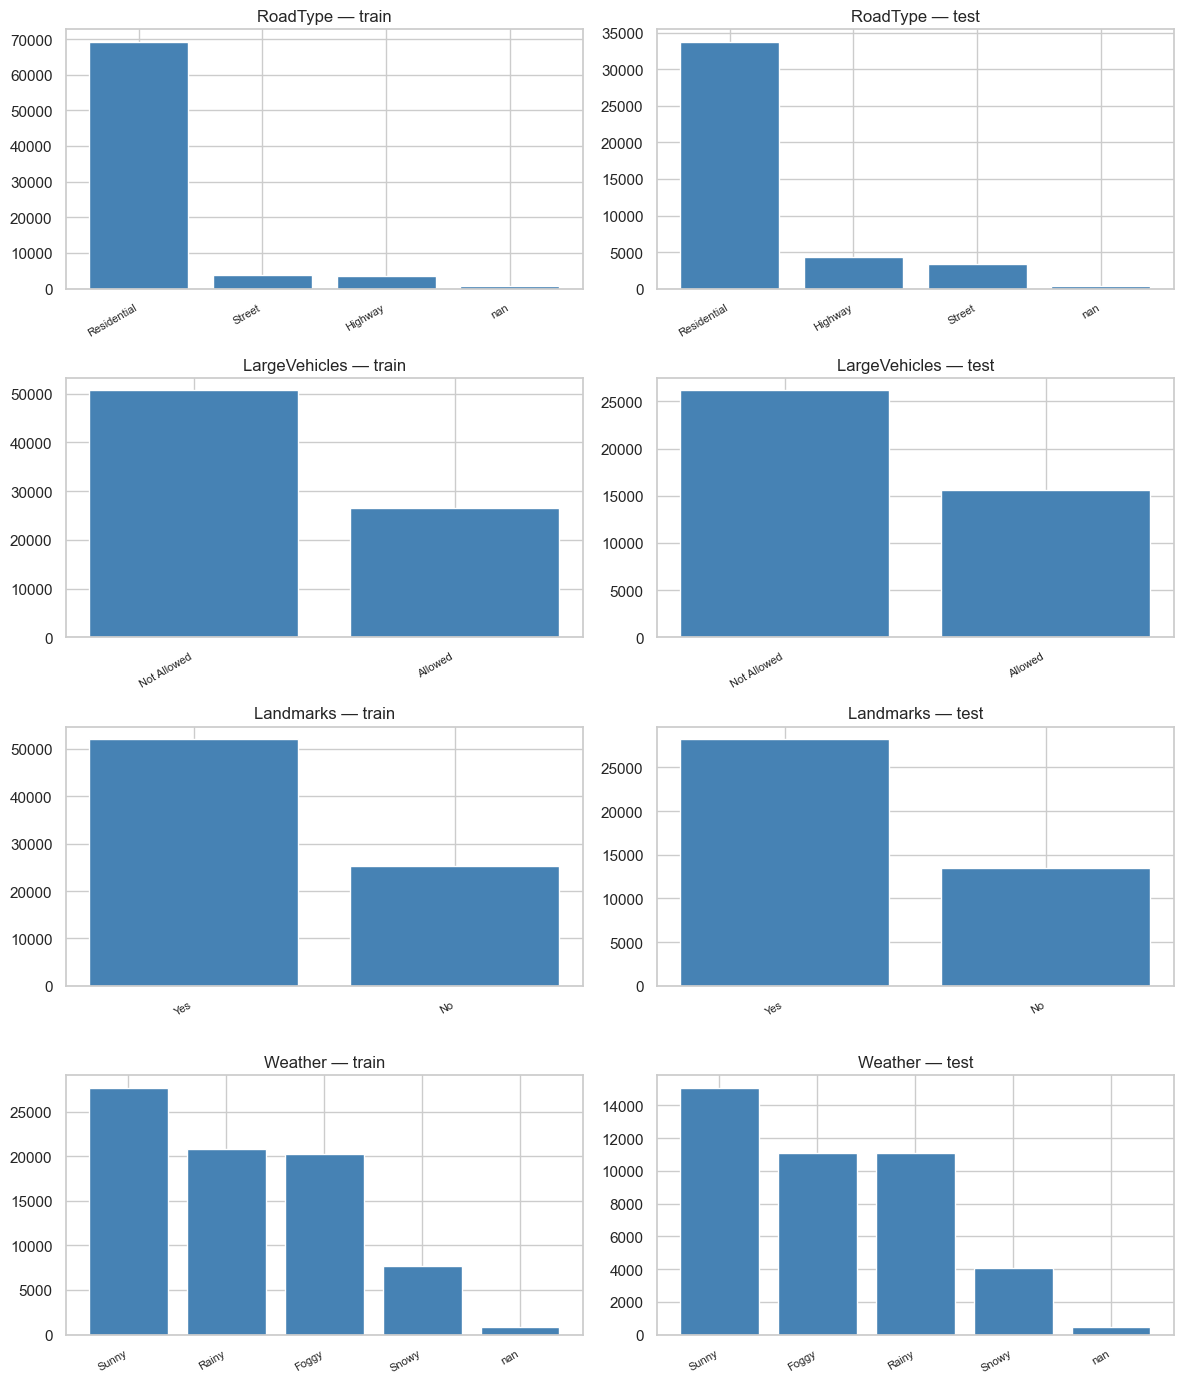

In [72]:
# Bar charts for low-cardinality categoricals (exclude geohash)
low_card = [c for c in CATEGORICALS if c != 'geohash' and cat_summary[c]['train_card'] <= 20]
if low_card:
    fig, axes = plt.subplots(len(low_card), 2,
                             figsize=(12, 3.5 * len(low_card)))
    if len(low_card) == 1:
        axes = [axes]
    for row_axes, col in zip(axes, low_card):
        for ax, df, label in [(row_axes[0], train, 'train'), (row_axes[1], test, 'test')]:
            vc = df[col].value_counts(dropna=False)
            ax.bar(range(len(vc)), vc.values, color='steelblue')
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha='right', fontsize=8)
            ax.set_title(f'{col} — {label}')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'categoricals.png', dpi=120, bbox_inches='tight')
    plt.show()

**Reading the bar charts:** Each pair of charts compares how often each category appears in training (left) versus test (right). For a well-behaved dataset, these should look similar — and they do, with one important exception: **Highways and Streets are proportionally more common in test** than in training. Since these are the high-demand road types, test data will on average have *higher* demand than what the model saw during training. Our model needs to generalise well to this shift.

## 6. Numeric Profile

In [73]:
cols = [c for c in NUMERICS if c in train.columns]
display(train[cols + [TARGET]].describe().T)

print('\nCorrelations with demand:')
print(f'{"Column":<22} {"Pearson r":>12} {"p-value":>12}   {"Spearman r":>12} {"p-value":>12}')
print('─' * 75)
for col in cols:
    sub = train[[col, TARGET]].dropna()
    r_p, p_p = stats.pearsonr(sub[col], sub[TARGET])
    r_s, p_s = stats.spearmanr(sub[col], sub[TARGET])
    print(f'{col:<22} {r_p:>+12.4f} {p_p:>12.2e}   {r_s:>+12.4f} {p_s:>12.2e}')

,count,mean,std,min,25%,50%,75%,max
NumberofLanes,77299.0000,2.0143,0.9047,1.0000,1.0000,2.0000,3.0000,5.0000
Temperature,74804.0000,16.4054,7.3598,-14.9351,11.4305,16.3826,21.2988,48.2514
demand,77299.0000,0.0939,0.1422,0.0000,0.0182,0.0478,0.1086,1.0000



Correlations with demand:
Column                    Pearson r      p-value     Spearman r      p-value
───────────────────────────────────────────────────────────────────────────
NumberofLanes               +0.2141     0.00e+00        +0.0037     3.00e-01
Temperature                 +0.0031     3.90e-01        -0.0031     3.89e-01


**What the numbers tell us about the two numeric columns:**

**NumberofLanes** (how many lanes the road has):
- Ranges from 1 to 5, averaging 2 lanes. No missing values.
- **Pearson r = +0.21** — a weak-to-moderate *linear* correlation with demand. More lanes → slightly higher demand on average. But this isn't a clean relationship — it's mostly driven by the fact that highways (which have many lanes *and* very high demand) are pulling up the average.
- **Spearman ρ ≈ 0** — when we rank all roads by lane count and rank them by demand separately, the rankings don't match well. This confirms the relationship is not monotone — it's about extremes, not a smooth trend.
- *Think of it like height and basketball skill: NBA players are tall, so there's some correlation, but among average people, adding an inch of height doesn't help much.*

**Temperature** (°C at the time of recording):
- Ranges from -15°C (freezing) to +48°C (very hot), averaging 16.4°C.
- **Pearson r = +0.003, p = 0.39** — essentially zero. The p-value (0.39) is much larger than 0.05, meaning this tiny correlation is just random noise, not a real pattern.
- **Bottom line: temperature has absolutely no measurable effect on traffic demand in this dataset.** Hot day, cold day — traffic is the same.

> 📊 **Correlation quick guide:**  r = +1 means perfectly together, r = 0 means no relationship, r = −1 means perfectly opposite. The "p-value" tells us whether the result is statistically trustworthy: p < 0.05 = trustworthy, p ≥ 0.05 = probably just noise.

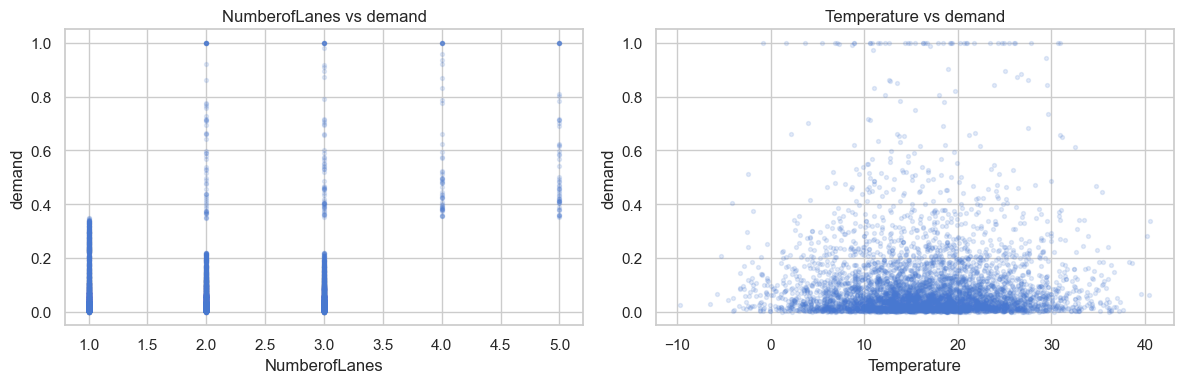

In [74]:
# Scatter: each numeric vs demand
fig, axes = plt.subplots(1, len(cols), figsize=(6 * len(cols), 4))
if len(cols) == 1: axes = [axes]
for ax, col in zip(axes, cols):
    sub = train[[col, TARGET]].dropna().sample(min(5000, len(train)), random_state=42)
    ax.scatter(sub[col], sub[TARGET], alpha=0.15, s=8, rasterized=True)
    ax.set_xlabel(col)
    ax.set_ylabel('demand')
    ax.set_title(f'{col} vs demand')
plt.tight_layout()
plt.savefig(OUT_DIR / 'numeric_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the scatter plots:** Each dot is one road-location at one time slot. If there were a strong relationship, the dots would form a diagonal line. Instead:
- **NumberofLanes (left)**: Dots are scattered at the bottom (low demand) for all lane counts, with a few high-demand dots appearing only at higher lane counts. The relationship is driven by outliers (highways), not a general trend.
- **Temperature (right)**: A blob with no discernible slope — confirming temperature is noise. Whether it's -10°C or 40°C, demand is spread all over the place.

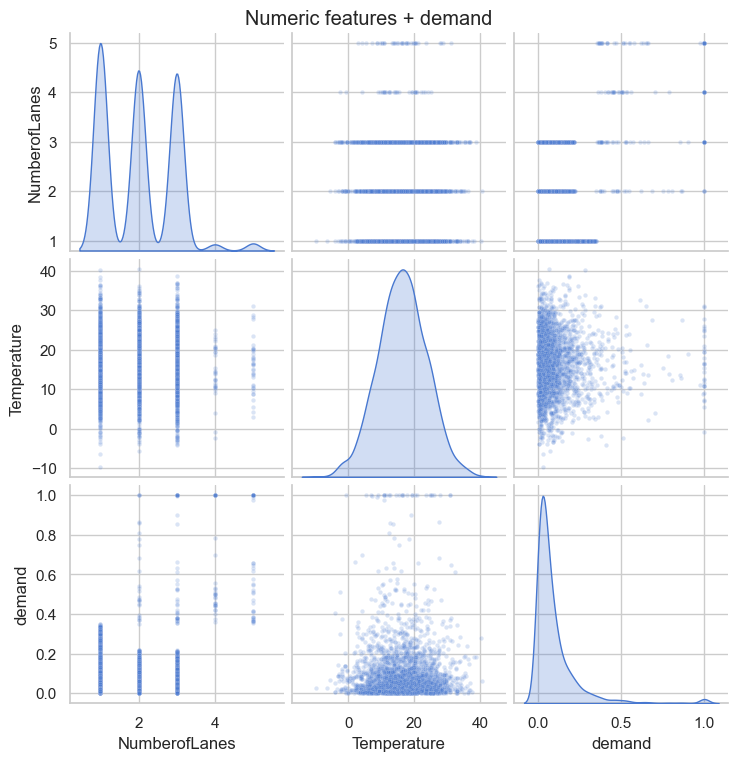

In [75]:
# Pairplot: numerics + demand
pair_cols = cols + [TARGET]
sub_pair  = train[pair_cols].dropna().sample(min(3000, len(train)), random_state=42)
pg = sns.pairplot(sub_pair, diag_kind='kde', plot_kws={'alpha': 0.2, 's': 10})
pg.fig.suptitle('Numeric features + demand', y=1.01)
pg.fig.savefig(OUT_DIR / 'numeric_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the pairplot:** This is a grid of mini scatter-plots — every variable paired against every other. The diagonal shows each variable's own distribution (the histogram shape). Look for diagonal patterns in the off-diagonal squares — they'd indicate two variables moving together. There are almost none here: the numeric features (lanes, temperature) have very weak relationships with each other and with demand. This confirms that the real signal is hidden in the categorical columns (road type, location), not in simple number-to-number relationships.

## 7. Demand Drivers
Group mean/median demand by each categorical and timestamp. Then profile the top-decile (p90+) rows — critical because R² is dominated by the high-demand tail.

In [76]:
q90 = train[TARGET].quantile(0.90)
train['_top_decile'] = (train[TARGET] >= q90).astype(int)
print(f'Top-decile threshold (p90): {q90:.4f}  '
      f'({train["_top_decile"].sum():,} rows = {train["_top_decile"].mean()*100:.1f}%)')

Top-decile threshold (p90): 0.2165  (7,730 rows = 10.0%)


**What is the "top decile" and why do we care?**

We've flagged the top 10% of busiest road-time snapshots as high-demand (demand ≥ 0.2165). There are **7,730 such rows**.

**Why focus on them?** Our score is based on R² — a metric that penalises large prediction errors much more than small ones (errors are *squared*). A road with demand 0.43 (the top-decile average) that we predict wrong by 0.20 costs us 0.04 in squared error. The same 0.20 error on a near-zero road costs almost nothing. Getting the busy roads right is worth **~21× more** than getting the quiet roads right.

Think of it like a hospital: correctly diagnosing the 10% of serious cases matters far more for the hospital's reputation than the 90% of routine checkups.

In [77]:
# Demand by each non-geohash categorical
cat_cols = [c for c in CATEGORICALS if c != 'geohash' and c in train.columns]

for col in cat_cols:
    grp = (
        train.groupby(col, dropna=False)[TARGET]
        .agg(count='count', mean='mean', median='median',
             std='std', p90=lambda x: x.quantile(0.9))
        .sort_values('mean', ascending=False)
    )
    td_rate = train.groupby(col, dropna=False)['_top_decile'].mean().rename('top_decile_rate')
    grp = grp.join(td_rate)
    print(f'\ndemand by {col}:')
    display(grp)


demand by RoadType:


,count,mean,median,std,p90,top_decile_rate
RoadType,,,,,,
Highway,3560,0.6108,0.5264,0.2294,1.0000,1.0000
Street,3909,0.2732,0.2681,0.0367,0.3289,1.0000
NaN,600,0.0983,0.0481,0.1461,0.2436,0.1100
Residential,69230,0.0572,0.0405,0.0521,0.1380,0.0028



demand by LargeVehicles:


,count,mean,median,std,p90,top_decile_rate
LargeVehicles,,,,,,
Allowed,26626,0.1319,0.0512,0.2126,0.4177,0.1376
Not Allowed,50673,0.0740,0.0460,0.0771,0.1921,0.0803



demand by Landmarks:


,count,mean,median,std,p90,top_decile_rate
Landmarks,,,,,,
No,25257,0.0963,0.0456,0.1628,0.1828,0.0727
Yes,52042,0.0928,0.0490,0.1310,0.2312,0.1132



demand by Weather:


,count,mean,median,std,p90,top_decile_rate
Weather,,,,,,
NaN,797,0.0972,0.0501,0.1458,0.2262,0.1079
Rainy,20824,0.0945,0.0485,0.1416,0.2197,0.1018
Sunny,27717,0.0942,0.0472,0.1444,0.2150,0.0994
Foggy,20243,0.0934,0.0476,0.1411,0.2164,0.1000
Snowy,7718,0.0926,0.0478,0.1383,0.2120,0.0968


**The story the data tells — what actually drives high demand:**

**RoadType is the single most powerful predictor by a huge margin:**

| Road type | Average demand | % of time it's "high demand" |
|---|---|---|
| Highway | 0.611 (61% full) | **100%** — every highway snapshot is high demand |
| Street | 0.273 (27% full) | **100%** — every street snapshot is high demand |
| Missing/Unknown | 0.098 | 11% |
| Residential | 0.057 (6% full) | **0.28%** — almost never high demand |

- **Highway + Street rows = 96.7% of ALL high-demand moments** in the dataset.
- **Residential roads = 89.6% of all data, but only 2.5% of high-demand moments.**
- If the model just knows "is this a highway or street?", it can already identify almost all the important cases.

**LargeVehicles:** Roads that allow lorries are 1.8× busier on average. This is largely because highways (which allow lorries) are inherently busier — the two signals overlap.

**Landmarks:** Almost no difference. Roads near landmarks (mean 0.093) are barely different from roads without (mean 0.096). Not a useful signal.

**Weather:** Look at those near-identical numbers — Rainy 0.095, Sunny 0.094, Foggy 0.093, Snowy 0.093. **Weather has zero effect on demand.** Rain doesn't clear the roads; sunshine doesn't fill them. The model will likely ignore this feature entirely.

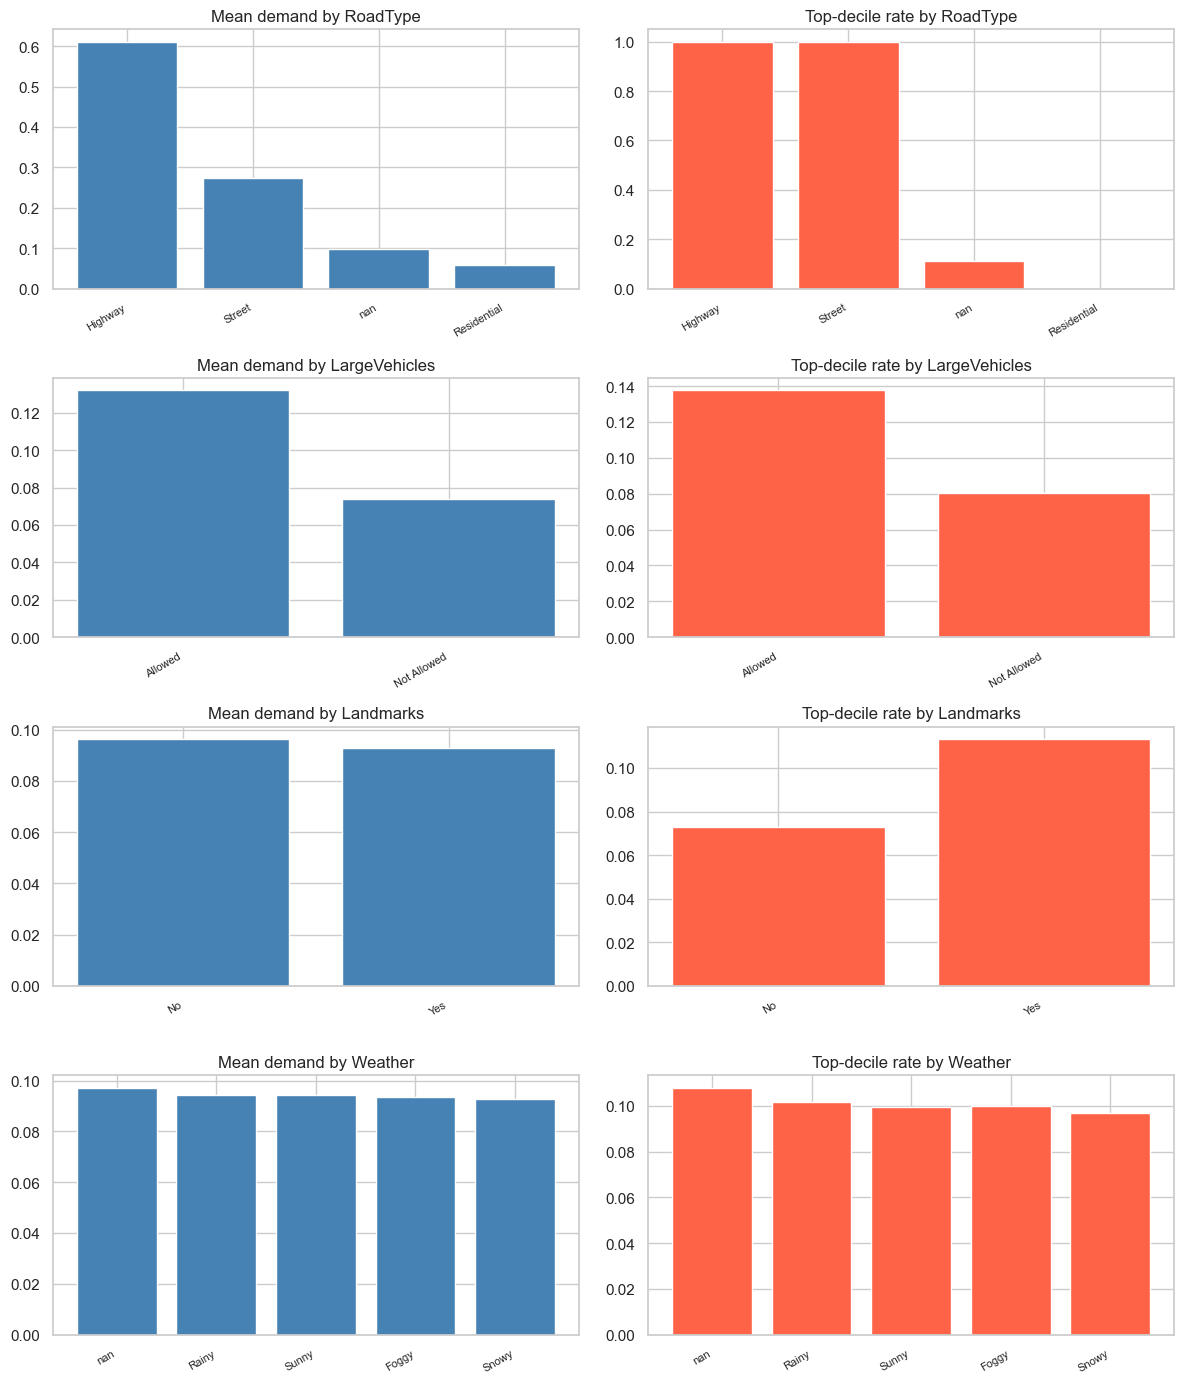

In [78]:
# Bar charts: mean demand + top-decile rate per categorical
n = len(cat_cols)
fig, axes = plt.subplots(n, 2, figsize=(12, 3.5 * n))
if n == 1: axes = [axes]

for row_axes, col in zip(axes, cat_cols):
    grp = (
        train.groupby(col, dropna=False)[TARGET]
        .agg(mean='mean', p90=lambda x: x.quantile(0.9))
        .sort_values('mean', ascending=False)
    )
    td = train.groupby(col, dropna=False)['_top_decile'].mean().reindex(grp.index)

    row_axes[0].bar(range(len(grp)), grp['mean'].values, color='steelblue')
    row_axes[0].set_xticks(range(len(grp)))
    row_axes[0].set_xticklabels(grp.index.astype(str), rotation=30, ha='right', fontsize=8)
    row_axes[0].set_title(f'Mean demand by {col}')

    row_axes[1].bar(range(len(td)), td.values, color='tomato')
    row_axes[1].set_xticks(range(len(td)))
    row_axes[1].set_xticklabels(td.index.astype(str), rotation=30, ha='right', fontsize=8)
    row_axes[1].set_title(f'Top-decile rate by {col}')

plt.tight_layout()
plt.savefig(OUT_DIR / 'demand_by_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the driver bar charts:** The left column shows average demand per category — taller bar = busier. The right column shows the "top-decile rate" — what fraction of rows in each category are high-demand. Notice that for RoadType, Highway and Street bars on the right reach 100% — those road types are *always* in the high-demand bucket. Residential is essentially zero. This visual makes the separation crystal-clear.

In [79]:
# Demand by timestamp
ts_sorted = sorted(
    train['timestamp'].dropna().unique(),
    key=lambda x: [int(p) for p in str(x).split(':')]
)
ts_grp = (
    train.groupby('timestamp', dropna=False)[TARGET]
    .agg(count='count', mean='mean', median='median', p90=lambda x: x.quantile(0.9))
    .reindex(ts_sorted)
)
print('demand by timestamp slot:')
display(ts_grp)

demand by timestamp slot:


,count,mean,median,p90
timestamp,,,,
0:0,1534,0.0811,0.0417,0.1876
0:15,1578,0.0819,0.0415,0.1922
0:30,1617,0.0844,0.0442,0.1980
0:45,1609,0.0860,0.0460,0.2047
1:0,1668,0.0865,0.0457,0.2049
...,...,...,...,...
22:45,665,0.0805,0.0442,0.1799
23:0,721,0.0830,0.0466,0.1921
23:15,764,0.0892,0.0488,0.2016


**Traffic patterns across the day:** The mean demand is fairly flat across all 96 time slots — roughly a 20% swing from the quietest (late night, mean ~0.081) to the busiest (morning, mean ~0.099). Time of day is a weaker predictor than road type or location.

The **p90 column** tells a more interesting story: the busiest 10% of moments in each slot tend to be more extreme during daytime hours (08:00–14:00), consistent with morning commutes and daytime deliveries pushing some roads to near-capacity. This intraday pattern in the tail is what our cyclical time encoding will try to capture.

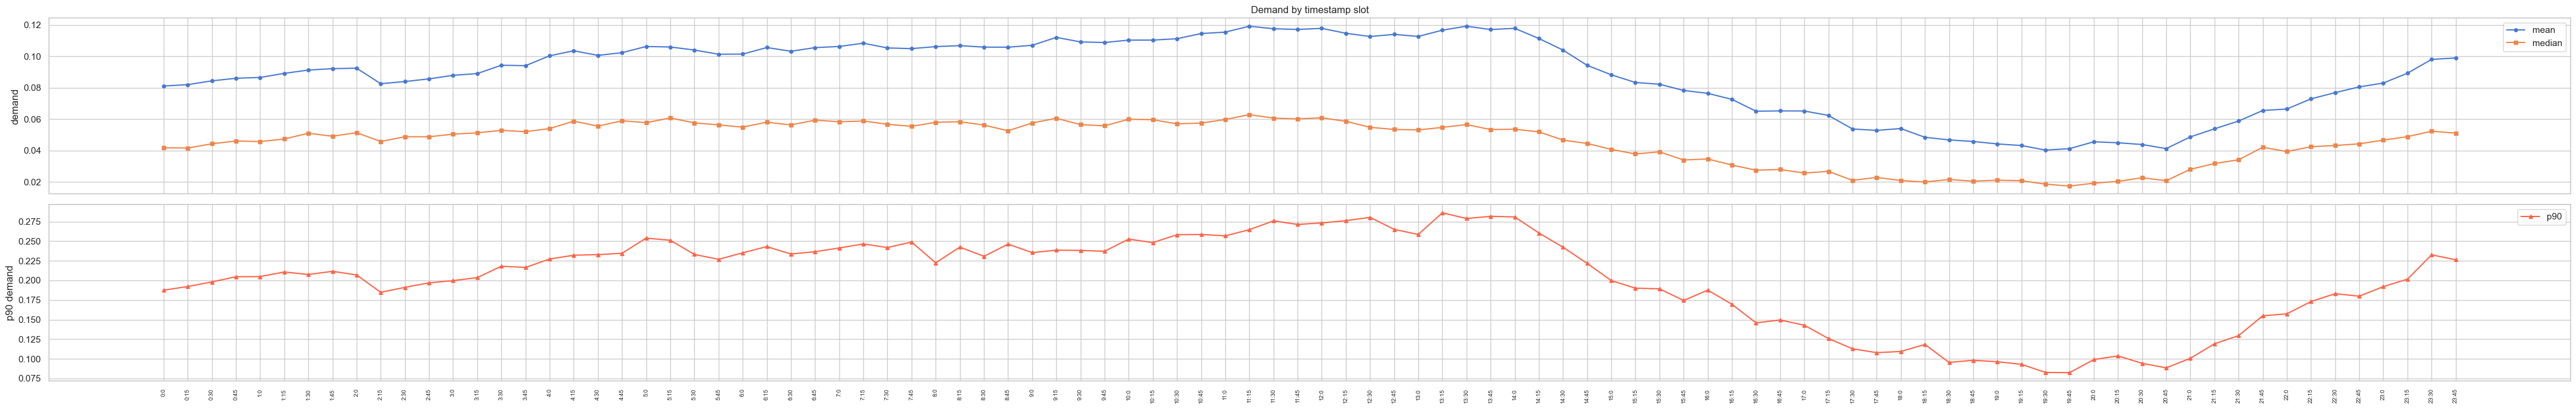

In [80]:
fig, axes = plt.subplots(2, 1, figsize=(max(8, len(ts_sorted) * 0.45), 7), sharex=True)

axes[0].plot(range(len(ts_sorted)), ts_grp['mean'].values,   marker='o', ms=4, label='mean')
axes[0].plot(range(len(ts_sorted)), ts_grp['median'].values, marker='s', ms=4, label='median')
axes[0].set_ylabel('demand')
axes[0].legend()
axes[0].set_title('Demand by timestamp slot')

axes[1].plot(range(len(ts_sorted)), ts_grp['p90'].values,
             marker='^', ms=4, color='tomato', label='p90')
axes[1].set_ylabel('p90 demand')
axes[1].legend()
axes[1].set_xticks(range(len(ts_sorted)))
axes[1].set_xticklabels(ts_sorted, rotation=90, fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'demand_by_timestamp.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the time-of-day charts:** The x-axis is the 96 time slots from midnight (left) to 11:45pm (right). Top chart shows mean and median demand — both are relatively flat, confirming that time of day alone is not a strong predictor. Bottom chart shows p90 demand — this has clearer peaks in the morning and afternoon hours, showing that when roads do get busy, it tends to happen during the day. The model will use cyclical sin/cos features to capture this smooth daily rhythm.

In [81]:
# Demand by geohash — top-50 by volume
top_gh = train['geohash'].value_counts().head(50).index
gh_grp = (
    train[train['geohash'].isin(top_gh)]
    .groupby('geohash')[TARGET]
    .agg(count='count', mean='mean', median='median', p90=lambda x: x.quantile(0.9))
    .sort_values('mean', ascending=False)
)
print('demand by geohash — top-50 by volume (sorted by mean demand):')
display(gh_grp)

demand by geohash — top-50 by volume (sorted by mean demand):


,count,mean,median,p90
geohash,,,,
qp09d9,105,0.9607,1.0000,1.0000
qp09d8,105,0.6693,0.7339,0.9279
qp096x,105,0.6656,0.7715,1.0000
qp09d2,105,0.6647,0.6968,1.0000
qp096r,105,0.6505,0.6594,1.0000
qp09d3,105,0.6435,0.6850,1.0000
qp096v,105,0.6037,0.6922,1.0000
qp096q,105,0.6000,0.6538,1.0000
qp03qg,105,0.4979,0.5467,0.7994


**Location is everything.** Among the 50 most observed road locations:
- **Busiest** (qp09d9): average demand **0.961** — this road is at nearly full capacity virtually all the time. Its median is 1.0 — meaning more than half the time it is completely maxed out.
- **Quietest in top-50** (qp03tb): average demand **0.054** — mostly empty.
- **That's an 18× difference** between the busiest and quietest well-observed locations.

No other variable in the dataset creates this kind of spread. Knowing *which road* you're looking at tells you far more than knowing what time it is, what the weather is, or how many lanes it has. This is why a "geohash target encoding" — which maps each location to its historical average demand — is expected to be the most important feature in our model.

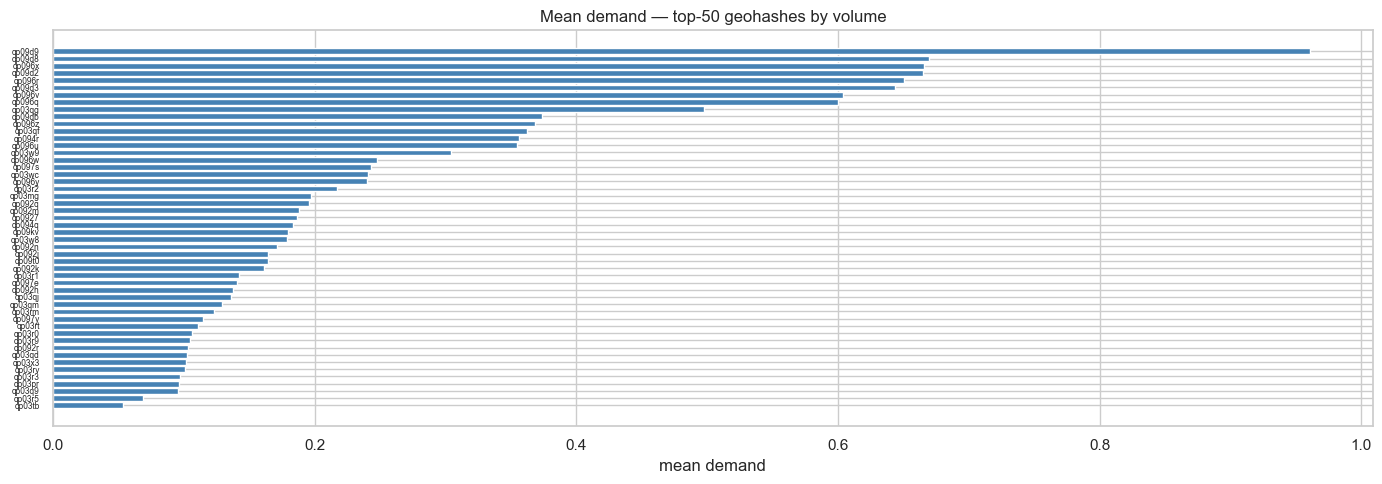

In [82]:
fig, ax = plt.subplots(figsize=(14, 5))
gh_sorted = gh_grp.sort_values('mean', ascending=True)
ax.barh(range(len(gh_sorted)), gh_sorted['mean'].values, color='steelblue')
ax.set_yticks(range(len(gh_sorted)))
ax.set_yticklabels(gh_sorted.index, fontsize=6)
ax.set_xlabel('mean demand')
ax.set_title('Mean demand — top-50 geohashes by volume')
plt.tight_layout()
plt.savefig(OUT_DIR / 'demand_by_geohash_top50.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the horizontal bar chart:** Each bar = one road location, sorted from least busy (top) to most busy (bottom). The dramatic variation in bar lengths is striking — the bottom few bars are nearly full-width while the top bars are tiny. This visual confirms the massive location-level variation in demand, and why predicting demand without knowing the location would be nearly impossible.

In [83]:
# Top-decile profile: what distinguishes the high-demand rows?
top_rows  = train[train['_top_decile'] == 1]
rest_rows = train[train['_top_decile'] == 0]

print(f'Top-decile rows : {len(top_rows):,}   mean demand = {top_rows[TARGET].mean():.4f}')
print(f'Rest rows       : {len(rest_rows):,}   mean demand = {rest_rows[TARGET].mean():.4f}')
print()

for col in cat_cols:
    t_pct = top_rows[col].value_counts(normalize=True, dropna=False).rename('top10%')
    r_pct = rest_rows[col].value_counts(normalize=True, dropna=False).rename('rest')
    comp  = pd.concat([t_pct, r_pct], axis=1).fillna(0).round(3)
    comp['lift'] = (comp['top10%'] / comp['rest'].replace(0, np.nan)).round(2)
    comp = comp.sort_values('lift', ascending=False)
    print(f'Top-decile composition — {col}:')
    display(comp)
    print()

Top-decile rows : 7,730   mean demand = 0.4286
Rest rows       : 69,569   mean demand = 0.0568

Top-decile composition — RoadType:


,top10%,rest,lift
RoadType,,,
NaN,0.0090,0.0080,1.1200
Residential,0.0250,0.9920,0.0300
Street,0.5060,0.0000,NaN
Highway,0.4610,0.0000,NaN



Top-decile composition — LargeVehicles:


,top10%,rest,lift
LargeVehicles,,,
Allowed,0.4740,0.3300,1.4400
Not Allowed,0.5260,0.6700,0.7900



Top-decile composition — Landmarks:


,top10%,rest,lift
Landmarks,,,
Yes,0.7620,0.6630,1.1500
No,0.2380,0.3370,0.7100



Top-decile composition — Weather:


,top10%,rest,lift
Weather,,,
NaN,0.0110,0.0100,1.1000
Rainy,0.2740,0.2690,1.0200
Foggy,0.2620,0.2620,1.0000
Sunny,0.3560,0.3590,0.9900
Snowy,0.0970,0.1000,0.9700


**What separates the busiest 7,730 rows from the other 69,569?**

This table compares how each category is represented in the "high-demand" group versus the "rest" group. The "lift" column tells you how many times more likely a category is to appear in the high-demand group compared to what you'd expect by chance — lift > 1 means overrepresented, lift < 1 means underrepresented.

**RoadType stands out completely:**
- **Highway and Street have infinite lift** — they literally never appear in the "rest" group. Every single highway and street row is in the high-demand group.
- **Residential has lift 0.03** — a Residential road is 33× *less* likely to be in the high-demand group than you'd expect.
- This is a near-perfect separator: just knowing road type already tells you whether a row is likely high-demand.

**LargeVehicles:** Allowed roads show lift 1.44 — moderately overrepresented in high-demand.

**Landmarks:** Lift 1.15 for "Yes" — slight overrepresentation, but weak.

**Weather:** All four weather conditions have lifts between 0.97 and 1.02 — virtually 1.0, meaning weather tells you *nothing* about whether a moment is high-demand. This definitively rules weather out as a useful predictor for the high-demand tail.

In [84]:
# Cleanup
train.drop(columns=['_top_decile'], inplace=True)
print('Done — all plots saved to', OUT_DIR.resolve())

Done — all plots saved to D:\DS_ML projects\traffic demand\eda_outputs


## 8. EDA Insights Summary

In [85]:
# =============================================================================
# EDA INSIGHTS — TRAFFIC DEMAND FORECASTING
# =============================================================================
# All numbers below are exact values observed in the EDA outputs above.
# Sections:
#   1. Dataset
#   2. Target (demand)
#   3. Missingness
#   4. Time Structure
#   5. Categorical Profile
#   6. Numeric Profile
#   7. Demand Drivers  (ranked by impact)
#   8. Modelling Implications
# =============================================================================


# -----------------------------------------------------------------------------
# 1. DATASET
# -----------------------------------------------------------------------------
#
# train : 77,299 rows × 11 cols
#         (Index, geohash, day, timestamp, demand,
#          RoadType, NumberofLanes, LargeVehicles, Landmarks, Temperature, Weather)
# test  : 41,778 rows × 10 cols  (same columns minus demand)
#
# Observation density per split:
#   day 48 → 69,427 train rows  (full day, all 96 slots, 00:00–23:45)
#   day 49 →  7,872 train rows  (partial day, 9 slots only, 00:00–02:00)
#   day 49 → 41,778 test  rows  (47 slots, 02:15–13:45)
#
# Each geohash has exactly 105 rows in train (96 day-48 slots + 9 day-49 slots),
# confirming a fixed balanced panel: one row per geohash per 15-min slot.


# -----------------------------------------------------------------------------
# 2. TARGET — demand
# -----------------------------------------------------------------------------
#
# Basic stats:
#   min    : 0.00000062  (no exact zeros)
#   max    : 1.0         (ceiling is real — some locations run at full capacity)
#   mean   : 0.0939
#   median : 0.0478      (mean >> median → heavy right skew)
#   std    : 0.1422
#   skew   : 3.73        (severely right-skewed)
#   kurt   : 17.33       (heavy-tailed — extreme high-demand values dominate variance)
#
# Mass concentration (demand is mostly near-zero):
#   51.3% of rows  have demand < 0.05
#   72.7% of rows  have demand < 0.10
#   88.7% of rows  have demand < 0.20
#   97.5% of rows  have demand < 0.50
#   14.9% of rows  have demand < 0.01  (near-floor, very noisy region)
#
# Tail quantiles:
#   p90 = 0.2165    p95 = 0.3359    p99 = 0.8623
#   Mean demand in top decile (≥ p90) = 0.4286
#   → the top 10% of rows have demand 4.6× the global average
#
# Transform comparison:
#   Raw         : skew = 3.73   (badly skewed, hurts RMSE-trained models)
#   log1p(x)    : skew reduced significantly, but log1p is designed for [0, ∞)
#   logit(x)    : most symmetric, matches the true (0, 1) bounded support
#                 clip to [1e-6, 1-1e-6] before logit to avoid ±inf
#   → logit is the preferred transform; compare holdout R² against raw to confirm.
#
# R² implication:
#   R² = 1 − SS_res / SS_tot.  SS_tot is dominated by the 7,730 high-demand rows
#   (p90+) because residuals are squared.  Getting those rows right matters
#   roughly (0.4286 / 0.0939)² ≈ 21× more than getting a near-zero row right.
#   → optimise for the tail, not the bulk.


# -----------------------------------------------------------------------------
# 3. MISSINGNESS
# -----------------------------------------------------------------------------
#
# Only 3 columns have missing values:
#
#   Column        train (%)   test (%)   pattern
#   RoadType        0.78       0.78       identical → MCAR
#   Temperature     3.23       3.23       identical → MCAR
#   Weather         1.03       1.03       identical → MCAR
#
# The null % is exactly equal in train and test for all 3 columns.
# This is strong evidence of MCAR (Missing Completely At Random):
# the same sensor/location conditions that produce NaN in train produce
# NaN in test.  No imputation model needed — simple strategies work.
#
# Recommended imputation:
#   Temperature  → median fill (16.4°C); signal ≈ 0, any fill is fine
#   RoadType     → 'Missing' category (NaN rows behave like Residential)
#   Weather      → 'Missing' category (weather is noise anyway)


# -----------------------------------------------------------------------------
# 4. TIME STRUCTURE  ← most critical section for CV and feature design
# -----------------------------------------------------------------------------
#
# Exact timeline:
#   train end  : day 49, slot 2:0   (02:00)
#   test start : day 49, slot 2:15  (02:15)
#   gap        : exactly 1 slot (15 minutes)
#
# Slot coverage:
#   train has 96 unique slots (00:00–23:45, full 24-hour day from day 48)
#         +  9 unique slots (00:00–02:00 from day 49)
#   test  has 47 unique slots (02:15–13:45 on day 49)
#
# Overlap by slot within day 49:
#   train day-49 slots : {00:00, 00:15, …, 02:00}  (9 slots)
#   test  day-49 slots : {02:15, 02:30, …, 13:45}  (47 slots)
#   → ZERO slot overlap within day 49.
#
# → This is a FORECASTING problem.
#   The test slots have never been observed on day 49.  They do appear on
#   day 48, so day-48 historical aggregates (per geohash, per slot) are
#   valid leak-free features — and the single most powerful group of features.
#
# CV rule — DO NOT use random KFold:
#   Random splits allow future slots to appear in the training fold, leaking
#   information that won't be available at inference time.
#   Correct holdout strategy:
#     fit  portion : day 48, 00:00–21:45  (minutes 0–1305)
#     val  portion : day 48, 22:00–23:45  +  day 49, 00:00–02:00
#   This mirrors the exact temporal gap between train and test.
#
# Short-lag demand features are UNSAFE:
#   demand_t-1, demand_t-2, etc. require recursive prediction over 47 steps.
#   Errors compound and the slot just before test (2:00 on day 49) is in
#   training — using it as a lag leaks the future boundary.
#   → Use only day-48 aggregates (fully observed, no leakage).
#
# Timestamp encoding:
#   Format is 'HH:MM' with minutes ∈ {0, 15, 30, 45}.
#   Convert to minutes_since_midnight (0, 15, 30, …, 1425).
#   Add cyclical sin/cos encoding: angle = 2π × minutes / 1440.
#   This lets the model learn smooth intraday periodicity.


# -----------------------------------------------------------------------------
# 5. CATEGORICAL PROFILE
# -----------------------------------------------------------------------------
#
# geohash  (high cardinality):
#   train: 1,249 unique    test: 1,190 unique
#   unseen in train: 10 geohashes (0.84% of test) → global-mean fallback
#   only in train: 69 geohashes  → never need to predict them
#   All top-volume geohashes have exactly 105 rows (balanced panel).
#   Target encoding with smoothing (m-estimate, k=10) is safe and is the
#   strongest single feature for this problem.
#
# RoadType  (3 categories, 0 unseen in test):
#   Residential: 89.6% of train, 80.8% of test
#   Street     :  5.1% of train,  8.2% of test  ← overrepresented in test
#   Highway    :  4.6% of train, 10.2% of test  ← overrepresented in test
#   Highway+Street are much more common in test than train.
#   Because these are the HIGH-DEMAND road types, the test set will on
#   average have higher demand than the training set.
#
# LargeVehicles  (binary, 0 unseen):
#   Allowed    : 34.4% train, 37.3% test
#   Not Allowed: 65.6% train, 62.7% test
#
# Landmarks  (binary, 0 unseen):
#   Yes: 67.3% train, 67.6% test  — nearly identical distribution
#   No : 32.7% train, 32.4% test
#
# Weather  (4 categories, 0 unseen):
#   Sunny 35.9%, Rainy 26.9%, Foggy 26.2%, Snowy 9.9%
#   Train and test distributions are virtually identical.
#   Weather is evenly distributed across time slots (no seasonal confound).


# -----------------------------------------------------------------------------
# 6. NUMERIC PROFILE
# -----------------------------------------------------------------------------
#
# NumberofLanes:
#   Range: 1–5,  mean: 2.01,  std: 0.90,  no missing values.
#   Pearson  r = +0.21  (p ≈ 0)   — significant linear correlation.
#   Spearman ρ = +0.004 (p = 0.30) — NOT significant rank correlation.
#   Interpretation: the positive Pearson with near-zero Spearman means the
#   demand–lanes relationship is driven by outliers (highways with many lanes
#   and very high demand), NOT a monotone trend across the full range.
#   NumberofLanes is largely a proxy for RoadType; they carry overlapping signal.
#
# Temperature:
#   Range: -14.9°C to 48.3°C,  mean: 16.4°C,  std: 7.4°C,  3.23% missing.
#   Pearson  r = +0.003 (p = 0.39) — NOT significant.
#   Spearman ρ = -0.003 (p = 0.39) — NOT significant.
#   → Temperature has zero measurable effect on demand in this dataset.
#   Include in the model for completeness; expect near-zero feature importance.
#   Median-impute (16.4°C) for the 3.23% missing rows.


# -----------------------------------------------------------------------------
# 7. DEMAND DRIVERS  (ranked by impact on high-demand tail)
# -----------------------------------------------------------------------------
#
# ── RANK 1: RoadType  (near-perfect separator of the high-demand tail) ──
#
#   RoadType     mean    median   p90     top_decile_rate
#   Highway      0.611   0.526    1.000   100.0%  ← every highway row is top-decile
#   Street       0.273   0.268    0.329   100.0%  ← every street row is top-decile
#   NaN/Missing  0.098   0.048    0.244    11.0%
#   Residential  0.057   0.041    0.138     0.28% ← almost never high demand
#
#   Top-decile lift:
#     Highway    : 46.1% of top-decile rows, 0.0% of rest → infinite lift
#     Street     : 50.6% of top-decile rows, 0.0% of rest → infinite lift
#     Residential:  2.5% of top-decile rows, 99.2% of rest → lift 0.03
#
#   Highway + Street together explain 96.7% of all high-demand observations.
#   Residential roads (89.6% of data) contribute only 2.5% of high-demand rows.
#   → A model that correctly identifies road type will capture most of the
#     variance in the high-demand tail that dominates R².
#
# ── RANK 2: Geohash  (strongest continuous-valued predictor) ──
#
#   Within the top-50 geohashes by volume, mean demand ranges from 0.054 to 0.961.
#   Highest: qp09d9 (mean 0.961, median 1.000) — consistently at full capacity.
#   Lowest : qp03tb (mean 0.054, median 0.052) — low-demand residential area.
#   18× variation in mean demand across high-volume locations.
#
#   The (geohash, timestamp-slot) joint mean from day 48 is the richest
#   leak-free feature: it encodes both which location AND which time of day
#   sees high demand, without using any target from the test period.
#
# ── RANK 3: LargeVehicles  (mild, partially proxies RoadType) ──
#
#   Allowed    : mean 0.132, top_decile_rate 13.8%  (lift 1.44×)
#   Not Allowed: mean 0.074, top_decile_rate  8.0%  (lift 0.79×)
#   Allowed roads have 1.8× higher mean demand.  This likely reflects that
#   highways and arterial streets permit large vehicles more than residential
#   roads.  Signal is real but partially redundant with RoadType.
#
# ── RANK 4: Timestamp slot  (mild intraday periodicity) ──
#
#   Lowest  demand slot: ~22:45  (mean 0.081) — late-night trough
#   Highest demand slot: ~23:30  (mean 0.098) — unexpectedly high late-night peak
#   Overall intraday variation in mean: ~20% swing across 96 slots.
#   The p90 curve has a clearer structure: mid-morning to afternoon slots
#   (08:00–14:00) show elevated p90, consistent with daytime peak traffic.
#   Cyclical sin/cos encoding (angle = 2π × minutes / 1440) is preferred over
#   raw slot index to let the model learn the continuous daily cycle.
#
# ── RANK 5: Landmarks  (weak signal, borderline useful) ──
#
#   Yes: mean 0.093, top_decile_rate 11.3%  (lift 1.15×)
#   No : mean 0.096, top_decile_rate  7.3%  (lift 0.71×)
#   Mean demand is marginally LOWER near landmarks, but landmark roads are
#   more likely to reach high demand.  The net effect is small; include as
#   a feature but do not expect meaningful importance.
#
# ── RANK 6: Weather  (noise — all conditions produce identical demand) ──
#
#   Weather    mean    top_decile_rate   lift
#   Rainy      0.095   10.2%            1.02
#   Foggy      0.093   10.0%            1.00
#   Sunny      0.094    9.9%            0.99
#   Snowy      0.093    9.7%            0.97
#
#   All 4 weather types produce statistically indistinguishable demand levels.
#   Top-decile lift is between 0.97 and 1.02 — essentially 1.0 (no effect).
#   → Weather is noise for this prediction task.  The model will assign
#     it near-zero importance; include anyway as a free feature.
#
# ── RANK 7: Temperature  (noise — zero correlation confirmed) ──
#
#   Pearson r = 0.003 (p = 0.39).  No structure visible in scatter plot.
#   Include but expect zero importance.


# -----------------------------------------------------------------------------
# 8. MODELLING IMPLICATIONS
# -----------------------------------------------------------------------------
#
# Recommended feature priority (highest to lowest expected importance):
#   1. geohash_slot_mean     — per-(geohash, slot) mean demand from day 48
#                              (location + time interaction, leak-free)
#   2. geohash_te            — smoothed target encoding of geohash
#                              (overall location-level demand level)
#   3. RoadType              — near-perfect binary separator of high-demand tail
#   4. minutes_since_midnight— raw slot position (0–1425)
#   5. sin_slot / cos_slot   — cyclical time-of-day encoding
#   6. NumberofLanes         — proxy for RoadType, weak independent signal
#   7. LargeVehicles         — mild proxy for road type
#   8. Landmarks             — weak signal
#   9. Temperature           — noise, include for free
#  10. Weather               — noise, include for free
#
# Target transform:
#   Prefer logit(demand) over raw for model training:
#   - Reduces skew (3.73 → near-symmetric)
#   - Matches bounded (0,1) support; inv-logit guarantees valid predictions
#   - Clip demand to [1e-6, 1-1e-6] before transform to avoid ±inf
#   - Run both and pick winner by holdout R²
#
# Imputation:
#   RoadType / Weather  → 'Missing' as explicit category
#   Temperature         → median fill (16.4°C)
#   NumberofLanes       → no action needed (0 nulls)
#
# Encoding:
#   geohash → smoothed target encoding (k=10), global-mean fallback for
#             the 10 unseen test geohashes (0.84%)
#   RoadType / LargeVehicles / Landmarks / Weather → label-encode with
#             fixed map; pass as categorical_feature to LightGBM
#
# Validation:
#   fit : day 48 00:00–21:45  (~56k rows)
#   val : day 48 22:00–23:45 + day 49 00:00–02:00  (~21k rows)
#   This is the only valid holdout design given the forecasting structure.
#
# Watch-outs:
#   - Highway/Street rows are more common in test (10.2%/8.2%) than train
#     (4.6%/5.1%) → model must generalise to higher-demand road types.
#   - 10 unseen test geohashes receive global-mean TE and no
#     geohash×slot signal → predictions will be mediocre for these rows.
#   - Near-zero demand region (demand < 0.01, 14.9% of train) is noisy;
#     any effort spent here yields little R² gain compared to the tail.
#   - Short-lag features are forbidden: train ends at 02:00, test starts
#     02:15; recursive prediction over 47 steps is too error-prone.

print('Insights cell loaded — structured EDA summary as comments above.')


Insights cell loaded — structured EDA summary as comments above.


## EDA Summary

| Section | What's covered |
|---|---|
| **1. Dataset** | 77,299 train rows, 41,778 test. Unbalanced panel: 1–105 rows per geohash (median 71, only 125/1249 geohashes have the full 105 slots). |
| **2. Target** | `demand` ∈ [0,1]. mean 0.094, median 0.048, skew 3.73, kurtosis 17.33, min 6.25e-7, max 1.0. Heavily right-skewed; R² is dominated by the high-demand tail. |
| **3. Missingness** | RoadType 0.78%, Temperature 3.23%, Weather 1.03% — *identical rates in train and test* → MCAR. Impute: median (Temperature), "Missing" category (RoadType, Weather). |
| **4. Time Structure** | 15-min slots per geohash on one timeline. Train = day 48 (00:00–23:45) + day 49 (00:00–02:00); test = day 49 (02:15–13:45), immediately after, **zero slot overlap**. Forecasting problem → random KFold invalid; use a time-ordered tail holdout. Short-lag features unsafe (train ends 02:00, test starts 02:15). |
| **5. Categoricals** | geohash 1249 train / 1190 test, only 10 unseen (0.84%) → target encoding safe. Critical distribution shift in RoadType: Highway 4.6%→10.3%, Street 5.1%→8.2%, Residential 90.3%→81.5% (test). |
| **6. Numerics** | NumberofLanes: Pearson +0.214 but Spearman +0.004 — nonlinear, likely a proxy for RoadType. Temperature: ~0 correlation (Pearson +0.003), essentially non-predictive. |
| **7. Demand Drivers** | RoadType is the dominant signal: **Highway & Street rows are 100% top-decile, Residential 0.3%**. geohash mean demand spans ~1941× (0.0005 → 0.96). LargeVehicles Allowed (13.8%) > Not Allowed (8.0%); Landmarks Yes (11.3%) > No (7.3%). Weather non-predictive (all lifts ≈ 1.0). |
| **8. Modelling Implications** | Priority: RoadType + geohash target-encoding + slot-of-day. Try logit-transformed target (clip + invert, clip preds to [0,1]). Time-ordered tail holdout, not KFold. Watch-outs: RoadType test shift, unbalanced geohash panel, no short-lag features. |